In [ ]:
print("Twitter Sentiment Analysis Project")

Twitter Sentiment Analysis Project


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [ ]:
data = {
    "Tweet":["Ilove this new phone, amazing experience",
             "Worst service ever,very disappointed",
             "The product is okay, nothing special",
             "Amazing quality and fast delivery",
             "I hate this app, it is useless"]
}
df = pd.DataFrame(data)
df

,Tweet
0,"Ilove this new phone, amazing experience"
1,"Worst service ever,very disappointed"
2,"The product is okay, nothing special"
3,Amazing quality and fast delivery
4,"I hate this app, it is useless"


In [9]:
import re
def clean_text(text):
  text = re.sub (r"http\S+", "", text)
  text = re.sub(r"@\w", "", text)
  text = re.sub(r"#\w+", "", text)
  text = re.sub(r"[^A-Za-z\s]", "", text)
  text = text.lower()
  text = text.strip()
  return text
  df["Clean_Tweet"] = df["Tweet"].apply(clean_text)
  df

In [10]:
print(df.columns)

Index(['Tweet'], dtype='object')


In [12]:
df["Clean_Tweet"] = df["Tweet"].str.lower()
df.head()

,Tweet,Clean_Tweet
0,"Ilove this new phone, amazing experience","ilove this new phone, amazing experience"
1,"Worst service ever,very disappointed","worst service ever,very disappointed"
2,"The product is okay, nothing special","the product is okay, nothing special"
3,Amazing quality and fast delivery,amazing quality and fast delivery
4,"I hate this app, it is useless","i hate this app, it is useless"


In [13]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.1 MB/s eta 0:00:00


In [20]:
df["Sentiment"] = "Neutral"
df.loc[df["Clean_Tweet"].str.contains("love|amazing|quality", case=False),
       "Sentiment"] = "Positive"
df.loc[df["Clean_Tweet"].str.contains("worst|hate|useless|disappointes",case=False), "Sentiment"] = "Negative"
df

,Tweet,Clean_Tweet,Sentiment
0,"Ilove this new phone, amazing experience","ilove this new phone, amazing experience",Positive
1,"Worst service ever,very disappointed","worst service ever,very disappointed",Negative
2,"The product is okay, nothing special","the product is okay, nothing special",Neutral
3,Amazing quality and fast delivery,amazing quality and fast delivery,Positive
4,"I hate this app, it is useless","i hate this app, it is useless",Negative


AttributeError: module 'matplotlib.pyplot' has no attribute 'ylable'

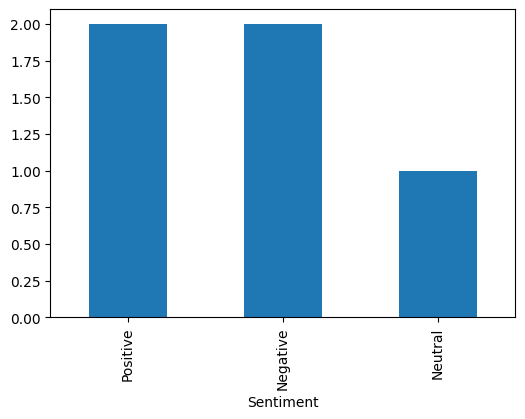

In [21]:
import matplotlib.pyplot as plt
sentiment_count = df["Sentiment"].value_counts()
plt.figure(figsize=(6,4))
sentiment_count.plot(kind="bar")
plt.xlabel("Sentiment")
plt.ylable("Number of Tweets")
plt.title("Tweet Sentiment Analysis")
plt.show()

In [23]:
!pip install wordcloud

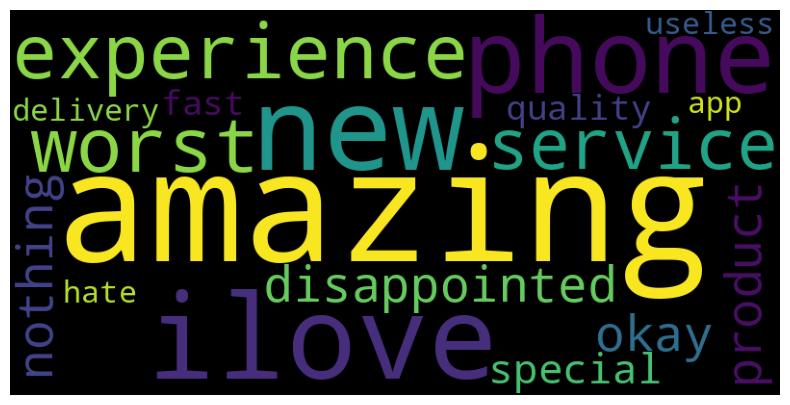

In [24]:
from wordcloud import WordCloud
text = " ".join(df["Clean_Tweet"])
wordcloud = WordCloud(width=800,height=400).generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [25]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 100.4 MB/s eta 0:00:00


In [27]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("Twitter Sentiment Analysis Dashboard")
st.write("Sentiment Analysis using NLP")


data = {
    "Sentiment":
    df["Sentiment"].value_counts().index,"Count":
    df["Sentiment"].value_counts().values
}
chart_df = pd.DataFrame(data)
st.subheader("Sentiment Count")
st.dataframe(chart_df)
fig, ax = plt.subplots()
ax.bar(chart_df["Sentiment"],
       chart_df["Count"])
plt.xlabel("Sentiment")
plt.ylabel("Count")
st.pyplot(fig)

Writing app.py


In [28]:
!streamlit run app.py &



2026-06-20 18:21:33.250 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.173.126.157:8501

  Stopping...


In [33]:
!streamlit run app.py --server.address=0.0.0.0 --server.port=8501 &



2026-06-20 18:33:10.523 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.173.126.157:8501

  Stopping...


In [38]:
!ls

app.py	sample_data
